# Comparativa global de modelos IoT

Este notebook unifica la comparativa final de los modelos del bloque IoT:

- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Linear SVM
- TensorFlow MLP
<!-- - LSTM -->
- CNN-1D

Se sigue la misma idea de `comparativaTodosModelos.ipynb`: entrenar cada ganador con todo el conjunto de train, medir la inferencia y comparar:

- `Latencia_ms`
- `Thruput (paq/s)`
- `Incremento RAM (MB)`
- `Porcentaje CPU`

Además se genera:

- una curva ROC conjunta de todos los modelos
- un panel de matrices de confusión

<!-- Nota metodológica original: `LSTM` se evalúa sobre secuencias temporales efectivas. -->
Nota metodológica: `CNN-1D` se evalúa en enfoque tabular, tratando cada flujo como un vector de caracteristicas con forma `(n_features, 1)`. La clase `1` corresponde a tráfico `Malicious`, por lo que la comparativa se centra en `F1_binary`.

In [1]:
import os
import time
import numpy as np
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
# from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

I0000 00:00:1777403486.206909 2486229 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777403486.255668 2486229 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777403487.413816 2486229 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Diccionario de Métricas de Evaluación

| Métrica | ¿Qué es y qué representa? (Significado Técnico) | ¿Cómo la hemos calculado? (Metodología de Código) |
| :--- | :--- | :--- |
| **F1-Score Binario** | Métrica de eficacia predictiva centrada en la clase positiva. En este cuaderno, la clase positiva es `Malicious (1)`, por lo que la métrica refleja qué tan bien detecta el modelo el tráfico malicioso equilibrando precisión y recall. | Calculada mediante `scikit-learn` con `f1_score(y_true, y_pred, average="binary")`, usando las etiquetas reales de test y las predicciones generadas por cada modelo. |
| **Latencia (ms)** | Tiempo medio amortizado por muestra durante la inferencia por lotes. Representa cuántos milisegundos reales cuesta procesar una muestra de IoT cuando el modelo evalúa un bloque completo. | Calculada midiendo el tiempo real transcurrido (*Wall Time* mediante `time.perf_counter()`) al procesar el set de test por lotes, dividido entre el número total de muestras procesadas. |
| **Throughput (paq/s)** | Caudal o ancho de banda de procesamiento. Representa el volumen de muestras que el modelo puede procesar por segundo sin convertirse en cuello de botella. | Obtenido dividiendo el número total de muestras del conjunto de test entre el tiempo físico total (*Wall Time* en segundos) que tardó en procesarlas. |
| **Incremento RAM (MB)** | Incremento de memoria residente observado durante la inferencia. Representa cuánta memoria física extra necesitó el proceso sobre su línea base al procesar los lotes del benchmark. | Monitorizando el proceso con `psutil.memory_info().rss`, restando la memoria base (antes del bucle de inferencia) al máximo RSS observado durante el procesamiento de los lotes. |
| **Porcentaje CPU** | Carga computacional global media durante la inferencia. Representa qué porcentaje de la capacidad total de CPU del servidor se utilizó mientras el modelo procesaba el conjunto de test. | Calculado como `((tiempo_cpu / tiempo_muro) / total_cpus_logicas) * 100`, usando `psutil` para medir el tiempo total de CPU del proceso y `time.perf_counter()` para el tiempo real transcurrido. |

En este benchmark no estamos midiendo el entrenamiento, sino la inferencia. Durante el entrenamiento, muchos modelos intentan usar toda la capacidad disponible del hardware. En la inferencia, en cambio, lo que interesa es cuánto tarda el modelo ya construido en clasificar nuevas muestras y qué recursos necesita para hacerlo.

In [2]:
# Configuración de visualización

sns.set_style("whitegrid")

HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0
TRAIN_DEVICE = "/GPU:0" if HAS_GPU else "/CPU:0"
INFER_DEVICE = "/CPU:0"

if HAS_GPU:
    print("GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.")
else:
    print("No hay GPU disponible. Todo el notebook se ejecutará en CPU.")

tf.keras.backend.clear_session()

# def create_sequences(X, y, time_steps):
#     Xs, ys = [], []
#     for i in range(len(X) - time_steps + 1):
#         Xs.append(X[i:(i + time_steps)])
#         ys.append(y[i + time_steps - 1])
#     return np.array(Xs), np.array(ys)

def build_mlp_model(input_dim, hidden_units):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(keras.layers.Dense(units, activation="relu"))
    model.add(keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# def build_lstm_model(time_steps, n_features, units, num_layers):
#     model = Sequential()
#     model.add(Input(shape=(time_steps, n_features)))
#     if num_layers == 1:
#         model.add(LSTM(units, unroll=True))
#     else:
#         model.add(LSTM(units, return_sequences=True, unroll=True))
#         model.add(Dropout(0.2))
#         model.add(LSTM(units, unroll=True))
#     model.add(Dropout(0.2))
#     model.add(Dense(1, activation="sigmoid"))
#     model.compile(optimizer="adam", loss="binary_crossentropy")
#     return model

DEFAULT_CNN_DROPOUT = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_CNN_DROPOUT):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)),
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def clone_keras_model_to_cpu(builder_fn, trained_model, *builder_args):
    with tf.device(INFER_DEVICE):
        cpu_model = builder_fn(*builder_args)
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

def benchmark_predict(predict_fn, X_eval, model_name, block_size=2048, warmup_size=1000, repetitions=3):
    if len(X_eval) == 0:
        raise ValueError(f"{model_name}: no hay muestras para benchmark.")

    proceso = psutil.Process(os.getpid())
    warmup = X_eval[:min(warmup_size, len(X_eval))]
    _ = predict_fn(warmup)

    tiempos_muro = []
    tiempos_cpu = []
    picos_ram = []

    for _ in range(repetitions):
        cpu_ini = proceso.cpu_times()
        ram_base = proceso.memory_info().rss / (1024 * 1024)
        pico_ram_rep = ram_base

        t0 = time.perf_counter()
        for inicio in range(0, len(X_eval), block_size):
            fin = inicio + block_size
            bloque = X_eval[inicio:fin]
            _ = predict_fn(bloque)

            ram_actual = proceso.memory_info().rss / (1024 * 1024)
            if ram_actual > pico_ram_rep:
                pico_ram_rep = ram_actual

        t1 = time.perf_counter()
        cpu_fin = proceso.cpu_times()

        tiempos_muro.append(t1 - t0)
        tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system))
        picos_ram.append(pico_ram_rep - ram_base)

    media_muro = float(np.mean(tiempos_muro))
    media_cpu = float(np.mean(tiempos_cpu))
    pico_max_ram = float(np.max(picos_ram))
    total_nucleos = psutil.cpu_count(logical=True)

    return {
        "Modelo": model_name,
        "Latencia_ms": round((media_muro / len(X_eval)) * 1000, 5),
        "Thruput (paq/s)": round(len(X_eval) / media_muro, 0),
        "Incremento RAM (MB)": round(pico_max_ram, 2),
        "CPU efectiva (%)": round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
    }

def register_outputs(container_benchmark, container_roc, container_cm, benchmark_row, model_name, y_true, y_pred, y_score):
    benchmark_row = dict(benchmark_row)
    benchmark_row["F1_binary"] = round(float(f1_score(y_true, y_pred, average="binary", zero_division=0)), 4)
    container_benchmark.append(benchmark_row)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    container_roc.append({"Modelo": model_name, "fpr": fpr, "tpr": tpr, "auc": roc_auc})
    container_cm.append({"Modelo": model_name, "cm": confusion_matrix(y_true, y_pred)})
    print(f"  -> {model_name}: F1={benchmark_row['F1_binary']:.4f} | AUC={roc_auc:.4f} | Acc={accuracy_score(y_true, y_pred):.4f}")


GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.


Analogía del Restaurante

Imagina que vas a un restaurante y quieres saber el tiempo total que han trabajado para ti para preparar tu plato:

    Tiempo user: Es el tiempo que el cocinero (tu modelo de Machine Learning) pasa haciendo cálculos para clasificar las muestras.

    Tiempo system: Es el tiempo que el camarero (el Sistema Operativo) pasa trayendo recursos, reservando memoria o gestionando tareas en nombre del proceso.

La fórmula completa:
(Tiempo del Cocinero final - Tiempo del Cocinero inicial) + (Tiempo del Camarero final - Tiempo del Camarero inicial)

In [3]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================

TARGET_COL = "label"
prepared_path = "../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_preparado.csv"

df_encoded = pl.read_csv(prepared_path)

feature_columns = [col for col in df_encoded.columns if col != TARGET_COL]
X = df_encoded.select(feature_columns)
y_np = df_encoded[TARGET_COL].to_numpy().astype(np.int8)
X_np = X.to_numpy()

indices = np.arange(X_np.shape[0])

train_full_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_np,
)

train_idx, val_idx = train_test_split(
    train_full_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_np[train_full_idx],
)

X_full_train_np = X_np[train_full_idx]
X_test_np = X_np[test_idx]
y_full_train = y_np[train_full_idx]
y_test_np = y_np[test_idx]

X_train_np = X_np[train_idx]
X_val_np = X_np[val_idx]
y_train_np = y_np[train_idx]
y_val_np = y_np[val_idx]

print(f"Entrenamiento: {len(X_train_np):,} muestras")
print(f"Validación:    {len(X_val_np):,} muestras")
print(f"Test:          {len(X_test_np):,} muestras")
print(f"Clases en test: {np.unique(y_test_np)}")
print(f"Total muestras: {len(X_np):,}")
print("La clase 0 corresponde a Benign y la clase 1 a Malicious.")

# ==========================================
# 2. CONFIGURACIÓN DE LOS GANADORES
# ==========================================

RF_CONFIG = {"n_estimators": 50, "max_depth": 21}
XGB_CONFIG = {"n_estimators": 50, "max_depth": 6, "learning_rate": 0.1}
LGBM_CONFIG = {"n_estimators": 50, "num_leaves": 15, "max_depth": 6, "learning_rate": 0.1}
CATBOOST_CONFIG = {"iterations": 350, "depth": 3, "learning_rate": 0.1}

SVM_C = 0.801714
MLP_INPUT_DIM = X_full_train_np.shape[1]
MLP_HIDDEN_UNITS = (32, 48, 48)
# LSTM_CONFIG = {"ts": 10, "u": 32, "l": 1}
CNN1D_CONFIG = {"nf": 64, "k": 4, "d": 80}


Entrenamiento: 745,504 muestras
Validación:    186,376 muestras
Test:          232,971 muestras
Clases en test: [0 1]
Total muestras: 1,164,851
La clase 0 corresponde a Benign y la clase 1 a Malicious.


In [4]:
# ==========================================
# 3. ENTRENAMIENTO, BENCHMARK Y MÉTRICAS
# ==========================================

benchmark_rows = []
roc_payloads = []
cm_payloads = []

X_test_np_arr = np.array(X_test_np)

print("Entrenando y evaluando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["n_estimators"],
    max_depth=RF_CONFIG["max_depth"],
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)
rf_model.fit(X_full_train_np, y_full_train)
rf_predict = lambda X: np.asarray(rf_model.predict(X)).astype(np.int8).ravel()
rf_score = lambda X: rf_model.predict_proba(X)[:, 1]
rf_benchmark = benchmark_predict(rf_predict, X_test_np_arr, "Random Forest", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, rf_benchmark, "Random Forest", y_test_np, rf_predict(X_test_np_arr), rf_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=XGB_CONFIG["n_estimators"],
    max_depth=XGB_CONFIG["max_depth"],
    learning_rate=XGB_CONFIG["learning_rate"],
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda" if HAS_GPU else "cpu",
    random_state=42,
)
xgb_model.fit(X_full_train_np, y_full_train)
xgb_model.set_params(device="cpu")
xgb_predict = lambda X: np.asarray(xgb_model.predict(X)).astype(np.int8).ravel()
xgb_score = lambda X: xgb_model.predict_proba(X)[:, 1]
xgb_benchmark = benchmark_predict(xgb_predict, X_test_np_arr, "XGBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, xgb_benchmark, "XGBoost", y_test_np, xgb_predict(X_test_np_arr), xgb_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=LGBM_CONFIG["n_estimators"],
    num_leaves=LGBM_CONFIG["num_leaves"],
    max_depth=LGBM_CONFIG["max_depth"],
    learning_rate=LGBM_CONFIG["learning_rate"],
    objective="binary",
    device_type="gpu" if HAS_GPU else "cpu",
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_full_train_np, y_full_train)
lgbm_model.set_params(device_type="cpu")
lgbm_predict = lambda X: np.asarray(lgbm_model.predict(X)).astype(np.int8).ravel()
lgbm_score = lambda X: lgbm_model.predict_proba(X)[:, 1]
lgbm_benchmark = benchmark_predict(lgbm_predict, X_test_np_arr, "LightGBM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, lgbm_benchmark, "LightGBM", y_test_np, lgbm_predict(X_test_np_arr), lgbm_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando CatBoost...")
cat_model = CatBoostClassifier(
    iterations=CATBOOST_CONFIG["iterations"],
    depth=CATBOOST_CONFIG["depth"],
    learning_rate=CATBOOST_CONFIG["learning_rate"],
    random_seed=42,
    logging_level="Silent",
    task_type="GPU" if HAS_GPU else "CPU"
)
cat_model.fit(X_full_train_np, y_full_train)
cat_predict = lambda X: np.asarray(cat_model.predict(X, task_type="CPU")).astype(np.int8).ravel()
cat_score = lambda X: cat_model.predict_proba(X, task_type="CPU")[:, 1]
cat_benchmark = benchmark_predict(cat_predict, X_test_np_arr, "CatBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cat_benchmark, "CatBoost", y_test_np, cat_predict(X_test_np_arr), cat_score(X_test_np_arr))


Entrenando y evaluando Random Forest...
  -> Random Forest: F1=0.9997 | AUC=1.0000 | Acc=0.9996

Entrenando y evaluando XGBoost...
  -> XGBoost: F1=0.9991 | AUC=0.9995 | Acc=0.9990

Entrenando y evaluando LightGBM...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

  -> LightGBM: F1=0.9998 | AUC=0.9999 | Acc=0.9998

Entrenando y evaluando CatBoost...
  -> CatBoost: F1=1.0000 | AUC=1.0000 | Acc=1.0000


In [5]:
# ==========================================

print("\nEntrenando y evaluando Linear SVM...")
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=SVM_C, dual=False, random_state=42, max_iter=2000)
)
svm_model.fit(X_full_train_np, y_full_train)
svm_predict = lambda X: np.asarray(svm_model.predict(X)).astype(np.int8).ravel()
svm_score = lambda X: svm_model.decision_function(X)
svm_benchmark = benchmark_predict(svm_predict, X_test_np_arr, "Linear SVM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, svm_benchmark, "Linear SVM", y_test_np, svm_predict(X_test_np_arr), svm_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando TensorFlow MLP...")
tf.keras.backend.clear_session()
mlp_scaler = StandardScaler()
X_train_scaled_mlp = mlp_scaler.fit_transform(X_full_train_np)
X_test_scaled_mlp = mlp_scaler.transform(X_test_np_arr)
with tf.device(INFER_DEVICE):
    mlp_model = build_mlp_model(MLP_INPUT_DIM, MLP_HIDDEN_UNITS)
    mlp_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    mlp_model.fit(
        X_train_scaled_mlp,
        y_full_train,
        validation_split=0.1,
        epochs=40,
        batch_size=2048,
        callbacks=[mlp_early],
        verbose=0
    )
mlp_model_cpu = clone_keras_model_to_cpu(build_mlp_model, mlp_model, MLP_INPUT_DIM, MLP_HIDDEN_UNITS)
def mlp_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def mlp_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
mlp_benchmark = benchmark_predict(mlp_predict_labels, X_test_scaled_mlp, "TensorFlow MLP", block_size=4096, warmup_size=1024)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, mlp_benchmark, "TensorFlow MLP", y_test_np, mlp_predict_labels(X_test_scaled_mlp), mlp_predict_scores(X_test_scaled_mlp))

# ==========================================

# print("\nEntrenando y evaluando LSTM...")
# tf.keras.backend.clear_session()
# lstm_scaler = StandardScaler()
# X_train_scaled_lstm = lstm_scaler.fit_transform(X_full_train_np)
# X_test_scaled_lstm = lstm_scaler.transform(X_test_np_arr)
# X_train_seq_lstm, y_train_seq_lstm = create_sequences(X_train_scaled_lstm, y_full_train, LSTM_CONFIG["ts"])
# X_test_seq_lstm, y_test_seq_lstm = create_sequences(X_test_scaled_lstm, y_test_np, LSTM_CONFIG["ts"])
# with tf.device(TRAIN_DEVICE):
#     lstm_model = build_lstm_model(LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
#     lstm_early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
#     lstm_model.fit(
#         X_train_seq_lstm,
#         y_train_seq_lstm,
#         validation_split=0.1,
#         epochs=20,
#         batch_size=1024,
#         callbacks=[lstm_early],
#         verbose=0
#     )
# lstm_model_cpu = clone_keras_model_to_cpu(build_lstm_model, lstm_model, LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
# def lstm_predict_labels(X):
#     with tf.device(INFER_DEVICE):
#         y_prob = lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
#     return (y_prob > 0.5).astype(np.int8)
# def lstm_predict_scores(X):
#     with tf.device(INFER_DEVICE):
#         return lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
# lstm_benchmark = benchmark_predict(lstm_predict_labels, X_test_seq_lstm, "LSTM", block_size=2048, warmup_size=512)
# register_outputs(benchmark_rows, roc_payloads, cm_payloads, lstm_benchmark, "LSTM", y_test_seq_lstm, lstm_predict_labels(X_test_seq_lstm), lstm_predict_scores(X_test_seq_lstm))

# ==========================================

print("\nEntrenando y evaluando CNN-1D...")
tf.keras.backend.clear_session()
cnn_scaler = MinMaxScaler()
X_train_scaled_cnn = cnn_scaler.fit_transform(X_full_train_np)
X_test_scaled_cnn = cnn_scaler.transform(X_test_np_arr)
X_train_tabular_cnn = X_train_scaled_cnn.reshape(X_train_scaled_cnn.shape[0], X_train_scaled_cnn.shape[1], 1)
X_test_tabular_cnn = X_test_scaled_cnn.reshape(X_test_scaled_cnn.shape[0], X_test_scaled_cnn.shape[1], 1)
with tf.device(INFER_DEVICE):
    cnn_model = build_cnn1d_model(X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
    cnn_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    cnn_model.fit(
        X_train_tabular_cnn,
        y_full_train,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[cnn_early],
        verbose=0
    )
cnn_model_cpu = clone_keras_model_to_cpu(build_cnn1d_model, cnn_model, X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
def cnn_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def cnn_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
cnn_benchmark = benchmark_predict(cnn_predict_labels, X_test_tabular_cnn, "CNN-1D", block_size=2048, warmup_size=512)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cnn_benchmark, "CNN-1D", y_test_np, cnn_predict_labels(X_test_tabular_cnn), cnn_predict_scores(X_test_tabular_cnn))



Entrenando y evaluando Linear SVM...
  -> Linear SVM: F1=0.9550 | AUC=0.9928 | Acc=0.9460

Entrenando y evaluando TensorFlow MLP...


I0000 00:00:1777403523.041041 2486229 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43417 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1777403523.051756 2486229 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43485 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1777403523.061601 2486229 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43485 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1777403523.072306 2486229 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43485 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:

  -> TensorFlow MLP: F1=0.9956 | AUC=0.9983 | Acc=0.9948

Entrenando y evaluando CNN-1D...
  -> CNN-1D: F1=0.9952 | AUC=0.9982 | Acc=0.9943



                TABLA GLOBAL DE RENDIMIENTO Y F1
shape: (7, 6)
┌────────────────┬─────────────┬─────────────────┬──────────────────┬──────────────────┬───────────┐
│ Modelo         ┆ Latencia_ms ┆ Thruput (paq/s) ┆ Incremento RAM   ┆ CPU efectiva (%) ┆ F1_binary │
│ ---            ┆ ---         ┆ ---             ┆ (MB)             ┆ ---              ┆ ---       │
│ str            ┆ f64         ┆ f64             ┆ ---              ┆ f64              ┆ f64       │
│                ┆             ┆                 ┆ f64              ┆                  ┆           │
╞════════════════╪═════════════╪═════════════════╪══════════════════╪══════════════════╪═══════════╡
│ Linear SVM     ┆ 0.00018     ┆ 5.684672e6      ┆ 2.01             ┆ 1.1              ┆ 0.955     │
│ LightGBM       ┆ 0.00047     ┆ 2.144772e6      ┆ 0.11             ┆ 100.6            ┆ 0.9998    │
│ CatBoost       ┆ 0.00102     ┆ 982856.0        ┆ 0.02             ┆ 69.2             ┆ 1.0       │
│ XGBoost        ┆ 0.00584 

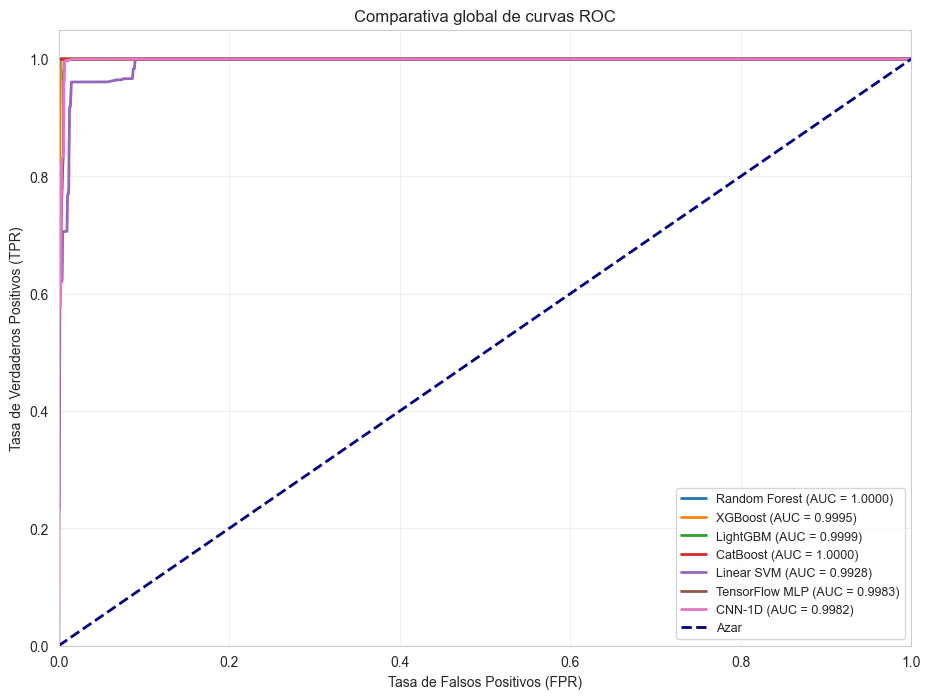

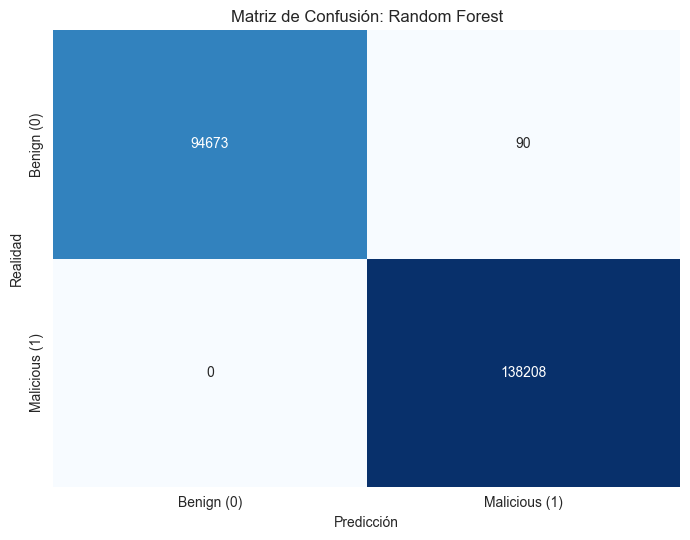

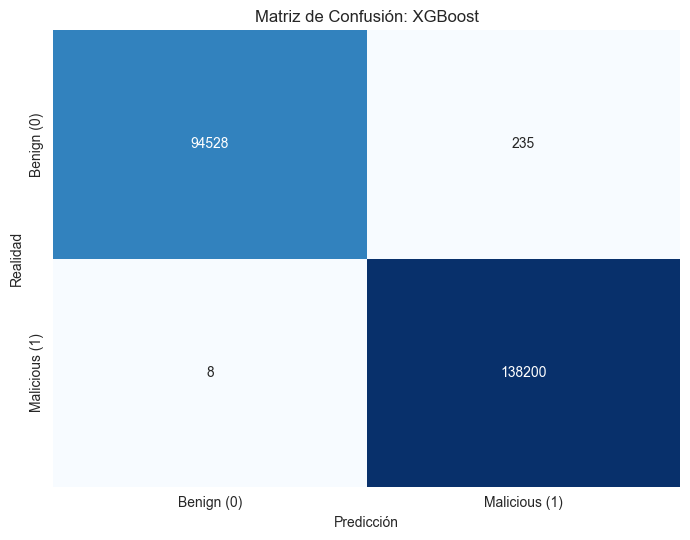

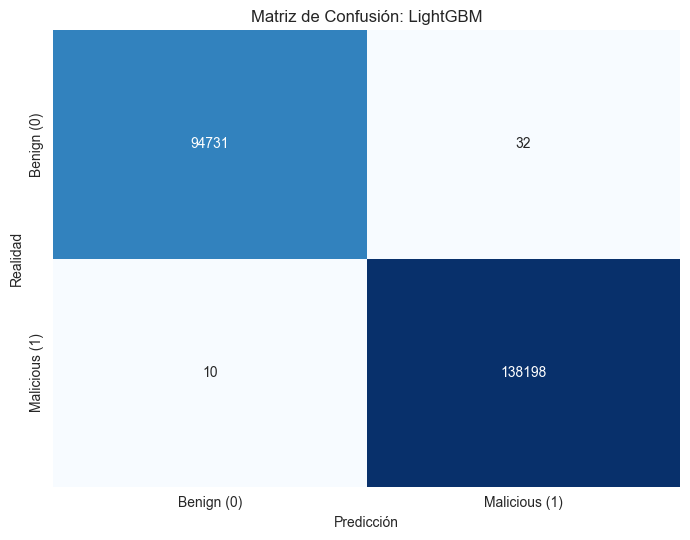

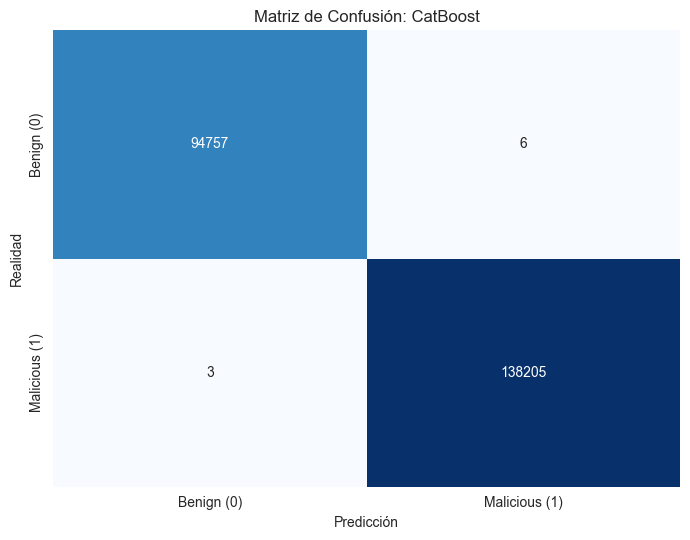

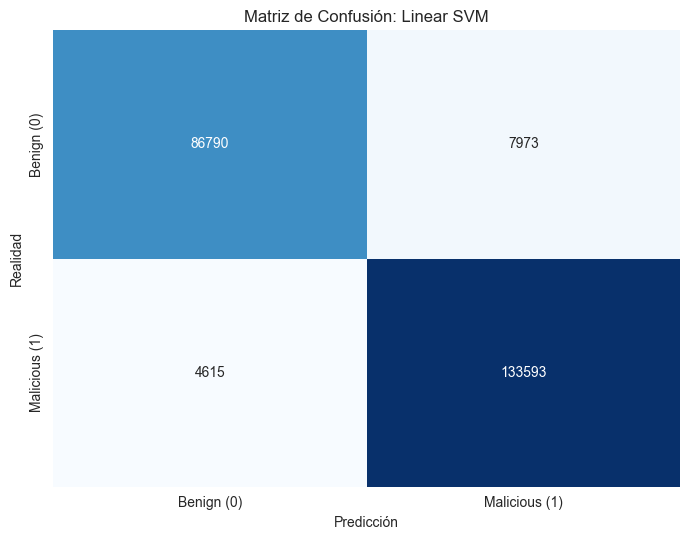

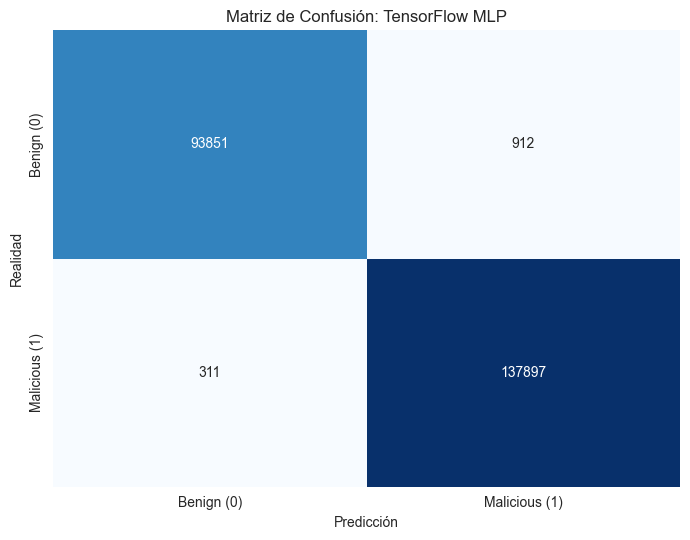

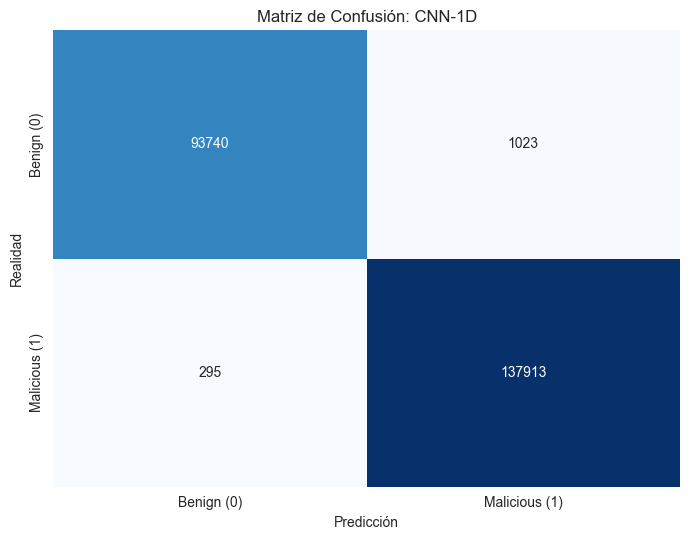

In [7]:
df_benchmark = pl.DataFrame(benchmark_rows).sort("Latencia_ms")
print("\n" + "=" * 95)
print("                TABLA GLOBAL DE RENDIMIENTO Y F1")
print("=" * 95)
print(df_benchmark)

plt.figure(figsize=(11, 8))
for payload in roc_payloads:
    plt.plot(payload["fpr"], payload["tpr"], lw=2, label=f"{payload['Modelo']} (AUC = {payload['auc']:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Azar")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Comparativa global de curvas ROC")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.show()

for payload in cm_payloads:
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(
        payload["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Benign (0)", "Malicious (1)"],
        yticklabels=["Benign (0)", "Malicious (1)"]
    )
    ax.set_title(f"Matriz de Confusión: {payload['Modelo']}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Realidad")
    plt.tight_layout()
    plt.show()
